In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
from kan import *
from kan.utils import ex_round
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from time import time
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


#### Data source: https://www.kaggle.com/datasets/nikunjhemani/freddie-macs-dataset-pre-processed/code
#### Feature selection: https://www.kaggle.com/code/missionjee/feature-selection

In [2]:
# Step 1: Load the Data
train_path = 'FreddieMac.csv'
test_path = 'FreddieMac.csv'
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

train_data['LTV_range'] = train_data['LTV_range'].map({'Low': -1, 'Medium': 0, 'High':1})
test_data['LTV_range'] = test_data['LTV_range'].map({'Low': -1, 'Medium': 0, 'High':1})
train_data['Credit_range'] = train_data['Credit_range'].map({'Poor': -1, 'Fair': 0, 'Good': 1})
test_data['Credit_range'] = test_data['Credit_range'].map({'Poor': -1, 'Fair': 0, 'Good': 1})
# Step 2: Prepare the Data
# [2:14] 14,13,2,9,10,6
'''features = df[['Repay_range', 'LTV_range', 'FirstTimeHomebuyer', 'NumBorrowers','MonthsInRepayment', 'OrigUPB', 
               'OrigInterestRate', 'MIP', 'Maturity_Year', 'FirstPayment_Year','MSA', 'DTI']].values'''

x_train = train_data.iloc[:, [14,10]].values  # Input columns
y_train = train_data.iloc[:, [15]].values  # Input columns
x_test = test_data.iloc[:, [14,10]].values  # Input columns
y_test = test_data.iloc[:, [15]].values  # Input columns

# Step 3: Min-Max Scaling
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

X_train = scaler_X.fit_transform(x_train)
X_test = scaler_X.transform(x_test)
Y_train = scaler_Y.fit_transform(y_train.reshape(-1, 1)).flatten()
Y_test = scaler_Y.transform(y_test.reshape(-1, 1)).flatten()

# Step 5: Convert to Torch Tensors and Create Dataset Format
train_input = torch.tensor(X_train, dtype=torch.double)
train_label = torch.tensor(Y_train, dtype=torch.double).unsqueeze(1)

test_input = torch.tensor(X_test, dtype=torch.double)
test_label = torch.tensor(Y_test, dtype=torch.double).unsqueeze(1)

# Creating the dataset dictionary
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': test_input,
    'test_label': test_label
}

print(X_test[:2,])

# Checking the shape of the tensors
print(dataset['train_input'].shape, dataset['train_label'].shape)
print(dataset['test_input'].shape, dataset['test_label'].shape)

[[0.25       0.24170616]
 [0.75       0.67772512]]
torch.Size([148938, 2]) torch.Size([148938, 1])
torch.Size([148938, 2]) torch.Size([148938, 1])


In [3]:
# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


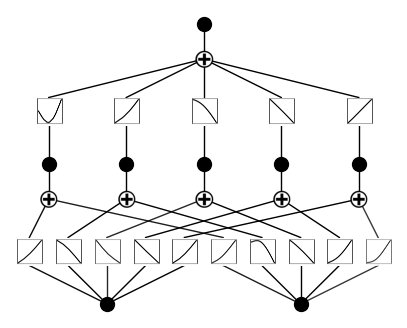

In [4]:
# plot KAN at initialization
model(dataset['train_input'])
model.plot()

In [5]:
# train the model
model.fit(dataset, opt="LBFGS", steps=100)

| train_loss: 2.18e-01 | test_loss: 2.18e-01 | reg: 1.25e+01 | : 100%|█| 100/100 [1:01:17<00:00, 36.


saving model version 0.1


{'train_loss': [array(0.21863413),
  array(0.21853139),
  array(0.21852011),
  array(0.21851215),
  array(0.21851005),
  array(0.21851107),
  array(0.21850977),
  array(0.21850831),
  array(0.21850741),
  array(0.21850654),
  array(0.21850701),
  array(0.21850597),
  array(0.21850579),
  array(0.21850555),
  array(0.21850544),
  array(0.21850583),
  array(0.21850558),
  array(0.21850549),
  array(0.21850539),
  array(0.21850518),
  array(0.21850483),
  array(0.2185047),
  array(0.21850445),
  array(0.21850418),
  array(0.21850406),
  array(0.21850437),
  array(0.21850412),
  array(0.21850406),
  array(0.21850399),
  array(0.21850394),
  array(0.21850396),
  array(0.21850392),
  array(0.21850384),
  array(0.21850378),
  array(0.21850373),
  array(0.21850382),
  array(0.21850371),
  array(0.21850361),
  array(0.21850338),
  array(0.21850306),
  array(0.21850214),
  array(0.2185017),
  array(0.21850125),
  array(0.21850087),
  array(0.21850055),
  array(0.21850024),
  array(0.21849988),
 

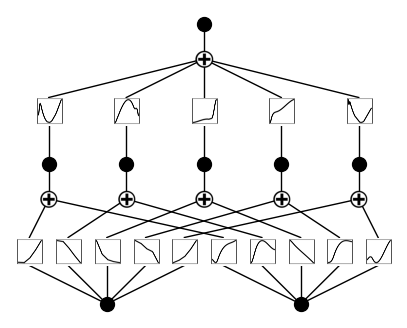

In [6]:
model.plot()

saving model version 0.2


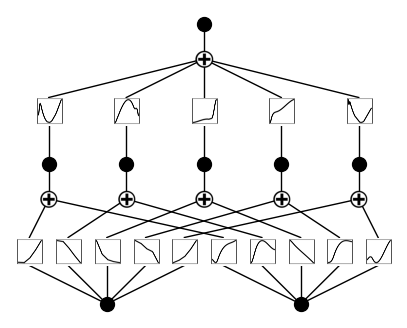

In [7]:
model = model.prune()
model.plot()

In [8]:
model.fit(dataset, opt="LBFGS", steps=100)

| train_loss: 2.18e-01 | test_loss: 2.18e-01 | reg: 1.44e+01 | : 100%|█| 100/100 [23:38:31<00:00, 85


saving model version 0.3


{'train_loss': [array(0.21851582),
  array(0.21850871),
  array(0.21850038),
  array(0.21849967),
  array(0.2184988),
  array(0.2185059),
  array(0.2185029),
  array(0.21850222),
  array(0.21850132),
  array(0.21850042),
  array(0.21850083),
  array(0.21850023),
  array(0.21849967),
  array(0.21849929),
  array(0.21849912),
  array(0.21850003),
  array(0.21849929),
  array(0.21849913),
  array(0.21849903),
  array(0.21849896),
  array(0.21849949),
  array(0.21849935),
  array(0.21849926),
  array(0.21849921),
  array(0.21849892),
  array(0.21849955),
  array(0.21849861),
  array(0.21849833),
  array(0.21849818),
  array(0.21849809),
  array(0.21850066),
  array(0.21849993),
  array(0.21849926),
  array(0.21849885),
  array(0.2184987),
  array(0.21850276),
  array(0.21849995),
  array(0.21849939),
  array(0.21849925),
  array(0.21849901),
  array(0.21849905),
  array(0.21849866),
  array(0.21849785),
  array(0.21849701),
  array(0.21849663),
  array(0.2185002),
  array(0.21849854),
  ar

In [9]:
model = model.refine(5)
model.fit(dataset, opt="LBFGS", steps=100)

saving model version 0.4


| train_loss: 2.18e-01 | test_loss: 2.18e-01 | reg: 1.43e+01 | : 100%|█| 100/100 [37:42:04<00:00, 13


saving model version 0.5


{'train_loss': [array(0.21871413),
  array(0.21855845),
  array(0.21851703),
  array(0.21850343),
  array(0.21850015),
  array(0.21853208),
  array(0.21850509),
  array(0.21850139),
  array(0.21849798),
  array(0.21849558),
  array(0.21855769),
  array(0.21851376),
  array(0.21850458),
  array(0.21849849),
  array(0.21849664),
  array(0.21850273),
  array(0.21849979),
  array(0.21849834),
  array(0.21849662),
  array(0.2184951),
  array(0.2184975),
  array(0.21849686),
  array(0.21849565),
  array(0.21849523),
  array(0.21849465),
  array(0.21854477),
  array(0.21849958),
  array(0.2184968),
  array(0.21849333),
  array(0.21849197),
  array(0.21850425),
  array(0.2184993),
  array(0.21849804),
  array(0.21849718),
  array(0.21849677),
  array(0.21849591),
  array(0.21849532),
  array(0.21849331),
  array(0.21849046),
  array(0.21848827),
  array(0.2184981),
  array(0.21849696),
  array(0.21849497),
  array(0.21849237),
  array(0.21849103),
  array(0.21849107),
  array(0.21848944),
  ar

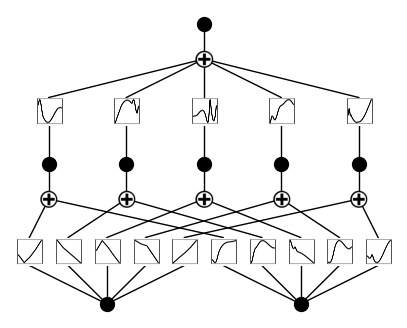

In [10]:
model.plot()

In [ ]:
model = model.refine(10)
model.fit(dataset, opt="LBFGS", steps=100)

saving model version 0.6


| train_loss: 2.18e-01 | test_loss: 2.18e-01 | reg: 0.00e+00 | :  14%|▏| 14/100 [16:50<1:37:56, 68.3

In [ ]:
model.plot()

model = model.refine(25)
model.fit(dataset, opt="LBFGS", steps=100)

model.plot()

In [ ]:
X_test = dataset['test_input']  # Shape: (n_samples, 6)
Y_test = dataset['test_label']  # Shape: (n_samples,)

Y_pred_KAN = model(X_test)

In [ ]:
X_test_np = X_test.cpu().numpy() if X_test.is_cuda else X_test.numpy()
Y_test_np = Y_test.cpu().numpy() if Y_test.is_cuda else Y_test.numpy()
Y_test_pred_np = Y_pred_KAN.cpu().detach().numpy() if Y_pred_KAN.is_cuda else Y_pred_KAN.detach().numpy()

# Combine X_test, Y_test, and Y_test_pred into a single DataFrame
data = np.hstack((X_test_np, Y_test_np.reshape(-1, 1), Y_test_pred_np.reshape(-1, 1)))
columns = [f"x{i+1}" for i in range(X_test_np.shape[1])] + ["y_test", "y_test_pred_KAN"]

# Create a DataFrame
df = pd.DataFrame(data, columns=columns)

# Export the DataFrame to a CSV file
output_file = "KAN_predictions.csv"
df.to_csv(output_file, index=False)

print(f"Predictions exported to {output_file}")


In [ ]:
Y_pred_KAN_np = Y_pred_KAN.detach().numpy()
y_pred_KAN = scaler_Y.inverse_transform(Y_pred_KAN_np)
#y_test = scaler_Y.inverse_transform(Y_test.reshape(-1, 1))

KAN_mae = mean_absolute_error(y_test, y_pred_KAN)
KAN_mape = np.mean(np.abs((y_test - y_pred_KAN) / y_test)) * 100  # Mean Absolute Percentage Error
KAN_mse = mean_squared_error(y_test, y_pred_KAN)
KAN_rmse = np.sqrt(KAN_mse)  # Root Mean Squared Error
KAN_rmspe = np.sqrt(np.mean(np.square((y_test - y_pred_KAN) / y_test))) * 100  # Root Mean Square Percentage Error
KAN_r2 = r2_score(y_test, y_pred_KAN)

# Printing the metrics
print(f"KAN Mean Absolute Error (MAE): {KAN_mae:.4f}")
print(f"KAN Mean Absolute Percentage Error (MAPE): {KAN_mape:.4f}%")
print(f"KAN Mean Squared Error (MSE): {KAN_mse:.4f}")
print(f"KAN Root Mean Squared Error (RMSE): {KAN_rmse:.4f}")
print(f"KAN Root Mean Square Percentage Error (RMSPE): {KAN_rmspe:.4f}%")
print(f"KAN R-squared (R2): {KAN_r2:.4f}")

In [ ]:
SYMBOLIC_LIB.keys()

In [ ]:
mode = "auto" # "manual"
t_init = time()

if mode == "manual":
    # manual mode
    model.fix_symbolic(0,0,0,'sin')
    model.fix_symbolic(0,1,0,'x^2')
    model.fix_symbolic(1,0,0,'exp')
elif mode == "auto":
    # automatic mode
    lib = ['x', 'x^0.5','x^2','x^3','x^4','1/x','1/x^0.5','1/x^2','1/x^3','1/x^4','exp','log','sqrt','tanh','sin','tan','abs', 'gaussian', 'sgn', '0']
    model.auto_symbolic(lib=None, weight_simple=0) # Lib none uses all of symbolic library, weight_simple asks for function fit complexity, 0 is complex and requires time
t_conv = time() - t_init
print("The conversion time is:",t_conv/60,"minutes.")

In [ ]:
output = ex_round(model.symbolic_formula()[0][0], 4)
print('After rounding, the formula is:\n',output)

output_type = type(output)
print('output type is', output_type)

In [ ]:
output

In [ ]:
# Assuming your symbolic expression (e.g., Y = x_1 + x_2 * x_3 + ...) 
# Replace this with your actual symbolic expression
x_1, x_2, x_3, x_4, x_5, x_6 = symbols('x_1 x_2 x_3 x_4 x_5 x_6') 
symbolic_expr = model.symbolic_formula()[0][0]

# Extract test data inputs and labels
X_test = dataset['test_input']  # Shape: (n_samples, 6)
Y_test = dataset['test_label']  # Shape: (n_samples,)

# List of symbols to map test_input to the symbolic expression
variables = [x_1, x_2, x_3, x_4, x_5, x_6]

In [ ]:
# Evaluate symbolic expression for each row in X_test
Y_pred_sym = []
for row in X_test:
    # Create a dictionary to map symbolic variables to values
    inputs = {var: value for var, value in zip(variables, row)}
    # Evaluate the symbolic expression and use evalf() to get a float value
    Y_pred_sym.append(float(symbolic_expr.subs(inputs).evalf()))

In [ ]:
# Convert predictions to NumPy array and reshape 
Y_pred_sym = np.array(Y_pred_sym).reshape(-1, 1)

# Inverse scale predictions and ground truth
y_pred_sym = scaler_Y.inverse_transform(Y_pred_sym)
#y_test = scaler_Y.inverse_transform(Y_test.reshape(-1, 1))

In [ ]:
# Compute R^2 score
sym_mae = mean_absolute_error(y_test, y_pred_sym)
sym_mape = np.mean(np.abs((y_test - y_pred_sym) / y_test)) * 100  # Mean Absolute Percentage Error
sym_mse = mean_squared_error(y_test, y_pred_sym)
sym_rmspe = np.sqrt(np.mean(np.square((y_test - y_pred_sym) / y_test))) * 100  # Root Mean Square Percentage Error
sym_rmse = np.sqrt(sym_mse)  # Root Mean Squared Error
sym_r2 = r2_score(y_test, y_pred_sym)

# Printing the metrics
print(f"Symbolic Mean Absolute Error (MAE): {sym_mae:.4f}")
print(f"Symbolic Mean Absolute Percentage Error (MAPE): {sym_mape:.4f}%")
print(f"Symbolic Mean Squared Error (MSE): {sym_mse:.4f}")
print(f"Symbolic Root Mean Squared Error (RMSE): {sym_rmse:.4f}")
print(f"Symbolic Root Mean Square Percentage Error (RMSPE): {sym_rmspe:.4f}%")
print(f"Symbolic R-squared (R2): {sym_r2:.4f}")

In [ ]:
# Combine X_test, Y_test, and Y_test_pred into a single DataFrame
data = np.hstack((X_test_np, Y_test_np.reshape(-1, 1), Y_test_pred_np.reshape(-1, 1)))
columns = [f"x{i+1}" for i in range(X_test_np.shape[1])] + ["y_test", "y_test_pred_KAN"]

# Create a DataFrame
df = pd.DataFrame(data, columns=columns)

# Export the DataFrame to a CSV file
output_file = "KAN_eqn_predictions.csv"
df.to_csv(output_file, index=False)

print(f"Predictions exported to {output_file}")